In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATA_DIR = Path("../data")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [8]:
# ================================================================
# STEP 1. 데이터 로드
# ================================================================
print("=" * 60)
print("STEP 1. 데이터 로드")
print("=" * 60)
 
df    = pd.read_csv(DATA_DIR / "sensor_hrv.csv")

# ts_start: 밀리초 Unix timestamp → datetime 변환
df["ts_start"] = pd.to_datetime(df["ts_start"], unit="ms")
df["ts_end"]   = pd.to_datetime(df["ts_end"],   unit="ms")
df["hour"]     = df["ts_start"].dt.hour
df["date"]     = df["ts_start"].dt.date

df.head()

STEP 1. 데이터 로드


,deviceId,ts_start,ts_end,missingness_score,hr,ibi,acc_x_avg,acc_y_avg,acc_z_avg,grv_x_avg,...,sdnn,sdsd,rmssd,pnn20,pnn50,lf,hf,lf/hf,hour,date
0,ab60,2021-04-01 07:33:45.031,2021-04-01 07:38:44.833,0.295448,84.592816,728.534374,0.284765,-0.593973,9.195984,-0.094203,...,89.363225,78.033038,98.417649,0.746269,0.391791,1818.065625,1252.992443,1.450979,7,2021-04-01
1,ab60,2021-03-26 05:33:37.151,2021-03-26 05:38:36.986,0.239085,78.589565,781.896913,3.050179,-1.239353,5.790543,-0.211973,...,100.804974,73.468687,106.602933,0.803704,0.540741,1918.499169,2784.393293,0.689019,5,2021-03-26
2,ab60,2021-03-26 05:28:37.083,2021-03-26 05:33:36.952,0.100773,75.620524,812.183910,2.153267,-3.546833,8.499866,-0.628970,...,89.073518,48.675496,74.504896,0.809816,0.484663,1292.696555,1034.550027,1.249525,5,2021-03-26
3,ab60,2021-03-26 05:23:37.077,2021-03-26 05:28:36.883,0.268178,85.813165,769.754943,2.898409,-3.401356,4.606113,-0.249247,...,102.371770,48.631219,70.615187,0.719178,0.400685,1561.785747,812.118619,1.923101,5,2021-03-26
4,ab60,2021-03-26 05:08:37.020,2021-03-26 05:13:36.839,0.794438,82.700133,842.902455,-2.272088,-7.464137,2.746394,0.458067,...,117.261385,93.239858,141.998289,0.843137,0.705882,2783.716123,5275.282999,0.527690,5,2021-03-26


In [9]:
# 파생 변수 계산
df['acc_mag'] = np.sqrt(df['acc_x_avg']**2 + df['acc_y_avg']**2 + df['acc_z_avg']**2)
df['hr_acc_ratio'] = df['hr'] / (df['acc_mag'] + 1)
df = df.rename(columns={'lf/hf': 'lfhf'})

features = ['hr', 'rmssd', 'pnn50', 'lfhf', 'acc_mag', 'hr_acc_ratio']
labels = {
    'hr': 'HR (bpm)',
    'rmssd': 'RMSSD (ms)',
    'pnn50': 'pNN50',
    'lfhf': 'LF/HF',
    'acc_mag': 'Acc Magnitude\nsqrt(x²+y²+z²)',
    'hr_acc_ratio': 'HR / (AccMag + 1)',
}

df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
hr,79639.0,83.578412,15.742021,39.562039,72.935277,81.396320,91.846722,200.224490
rmssd,77632.0,110.151593,63.676186,0.000000,68.132358,93.774405,136.368222,855.839188
pnn50,77632.0,0.455318,0.211078,0.000000,0.302403,0.428571,0.584906,1.000000
lfhf,77065.0,0.818635,1.156579,0.000000,0.383864,0.615941,0.986835,126.193879
acc_mag,79084.0,8.352016,1.453757,0.290165,7.521558,8.636220,9.583780,14.772700
hr_acc_ratio,79084.0,9.303518,3.122946,3.702591,7.374285,8.712039,10.467294,112.619760


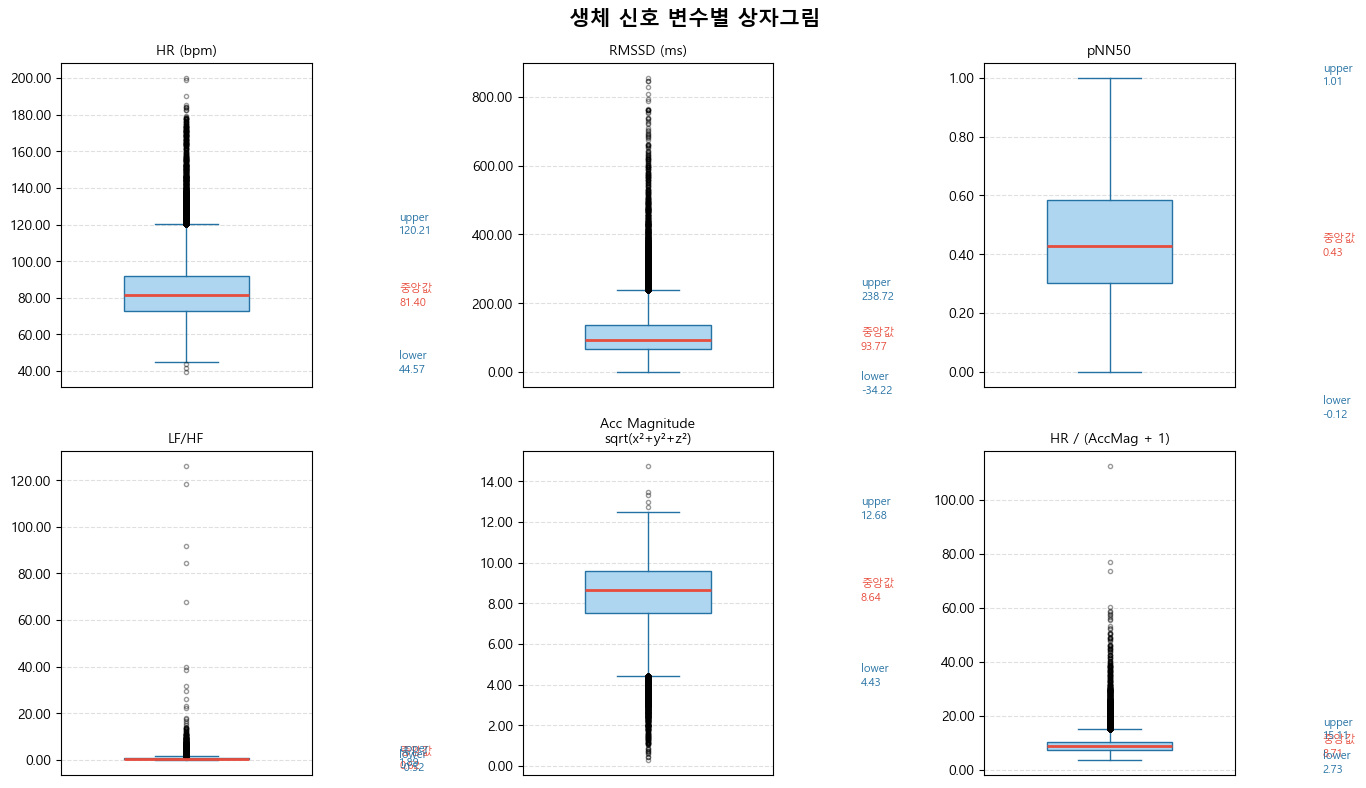

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('생체 신호 변수별 상자그림', fontsize=15, fontweight='bold')

for ax, feat in zip(axes.flat, features):
    data = df[feat].dropna()

    ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor='#AED6F1', color='#2471A3'),
        medianprops=dict(color='#E74C3C', linewidth=2),
        whiskerprops=dict(color='#2471A3'),
        capprops=dict(color='#2471A3'),
        flierprops=dict(marker='o', color='#E74C3C', alpha=0.4, markersize=3),
    )

    q1, med, q3 = data.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    ax.set_title(labels[feat], fontsize=10)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # 중앙값
    ax.text(1.35, med, f'중앙값\n{med:.2f}',
            transform=ax.get_yaxis_transform(),
            va='center', fontsize=8, color='#E74C3C')

    # upper / lower bound
    ax.text(1.35, upper, f'upper\n{upper:.2f}',
            transform=ax.get_yaxis_transform(),
            va='center', fontsize=8, color='#2471A3')
    ax.text(1.35, lower, f'lower\n{lower:.2f}',
            transform=ax.get_yaxis_transform(),
            va='center', fontsize=8, color='#2471A3')

plt.tight_layout()
plt.show()


In [12]:
df['acc_mag'] = np.sqrt(df['acc_x_avg']**2 + df['acc_y_avg']**2 + df['acc_z_avg']**2)
df['hr_acc_ratio'] = df['hr'] / (df['acc_mag'] + 1)
df = df.rename(columns={'lf/hf': 'lfhf'})

features = ['hr', 'rmssd', 'pnn50', 'lfhf', 'acc_mag', 'hr_acc_ratio']

for feat in features:
    data = df[feat].dropna()
    q1, med, q3 = data.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    print(f"[{feat}]")
    print(f"  Lower Bound : {lower:.4f}")
    print(f"  Q1          : {q1:.4f}")
    print(f"  Median      : {med:.4f}")
    print(f"  Q3          : {q3:.4f}")
    print(f"  Upper Bound : {upper:.4f}")
    print()


[hr]
  Lower Bound : 44.5681
  Q1          : 72.9353
  Median      : 81.3963
  Q3          : 91.8467
  Upper Bound : 120.2139

[rmssd]
  Lower Bound : -34.2214
  Q1          : 68.1324
  Median      : 93.7744
  Q3          : 136.3682
  Upper Bound : 238.7220

[pnn50]
  Lower Bound : -0.1214
  Q1          : 0.3024
  Median      : 0.4286
  Q3          : 0.5849
  Upper Bound : 1.0087

[lfhf]
  Lower Bound : -0.5206
  Q1          : 0.3839
  Median      : 0.6159
  Q3          : 0.9868
  Upper Bound : 1.8913

[acc_mag]
  Lower Bound : 4.4282
  Q1          : 7.5216
  Median      : 8.6362
  Q3          : 9.5838
  Upper Bound : 12.6771

[hr_acc_ratio]
  Lower Bound : 2.7348
  Q1          : 7.3743
  Median      : 8.7120
  Q3          : 10.4673
  Upper Bound : 15.1068

